# Medidas de heterogeneidad

Elegimos escolaridad, estado civil, estrato socioeconómico, condiciones económicas y violencia de pareja para revisar qué tan repartidas están sus categorías.

In [1]:
from pathlib import Path
import sys
import os
import tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "endireh-matplotlib"))
PROYECTO = Path.cwd().resolve()
if PROYECTO.name == "notebooks":
    PROYECTO = PROYECTO.parent
if str(PROYECTO) not in sys.path:
    sys.path.insert(0, str(PROYECTO))
import polars as pl
from IPython.display import display, Image
from config.rutas import ARCHIVO_ENDIREH_PROCESADO, RUTA_FIGURAS
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_rows(40)
pl.Config.set_float_precision(4)
df = pl.read_parquet(ARCHIVO_ENDIREH_PROCESADO)
print(f"Registros: {df.height:,}, columnas: {df.width}, Polars {pl.__version__}")


Registros: 105,715, columnas: 31, Polars 1.44.2


## Cálculos

Usamos estas fórmulas, donde p es la proporción de cada categoría y k es el número de categorías:

- Gini-Simpson: GS = 1 − Σp²
- IQV = k·GS/(k−1)
- Shannon: H = −Σp·log₂(p)

Shannon se mide en bits y su máximo es log₂(k). El IQV va de 0 a 1. Si solo hay una categoría, los tres índices son cero. No contamos los datos faltantes.

En esta parte usamos frecuencias sin ponderar para describir la muestra. Las funciones están en `src.analysis.indices`.

In [2]:
from src.analysis.medidas_heterogeneidad import medidas_heterogeneidad, generar_grafica_iqv
heterogeneidad = medidas_heterogeneidad(df)
display(heterogeneidad)
generar_grafica_iqv(heterogeneidad)

variable,k_categorias,Gini_Simpson,IQV,Shannon_Entropy
str,i64,f64,f64,f64
"""dinero_propio_desc""",2,0.4976,0.9952,0.9965
"""pareja_trabaja_desc""",2,0.4971,0.9943,0.9959
"""propietaria_vivienda_desc""",2,0.4507,0.9013,0.9276
"""estado_civil_desc""",6,0.7455,0.8945,2.2176
"""estrato_socioeconomico""",4,0.6424,0.8565,1.7136
"""nivel_escolaridad""",6,0.6127,0.7353,1.8481
"""sufrio_violencia_pareja""",2,0.2973,0.5945,0.6836
"""apoyo_gobierno_desc""",2,0.2403,0.4806,0.5834
"""tiene_ahorros_desc""",2,0.1992,0.3984,0.5064


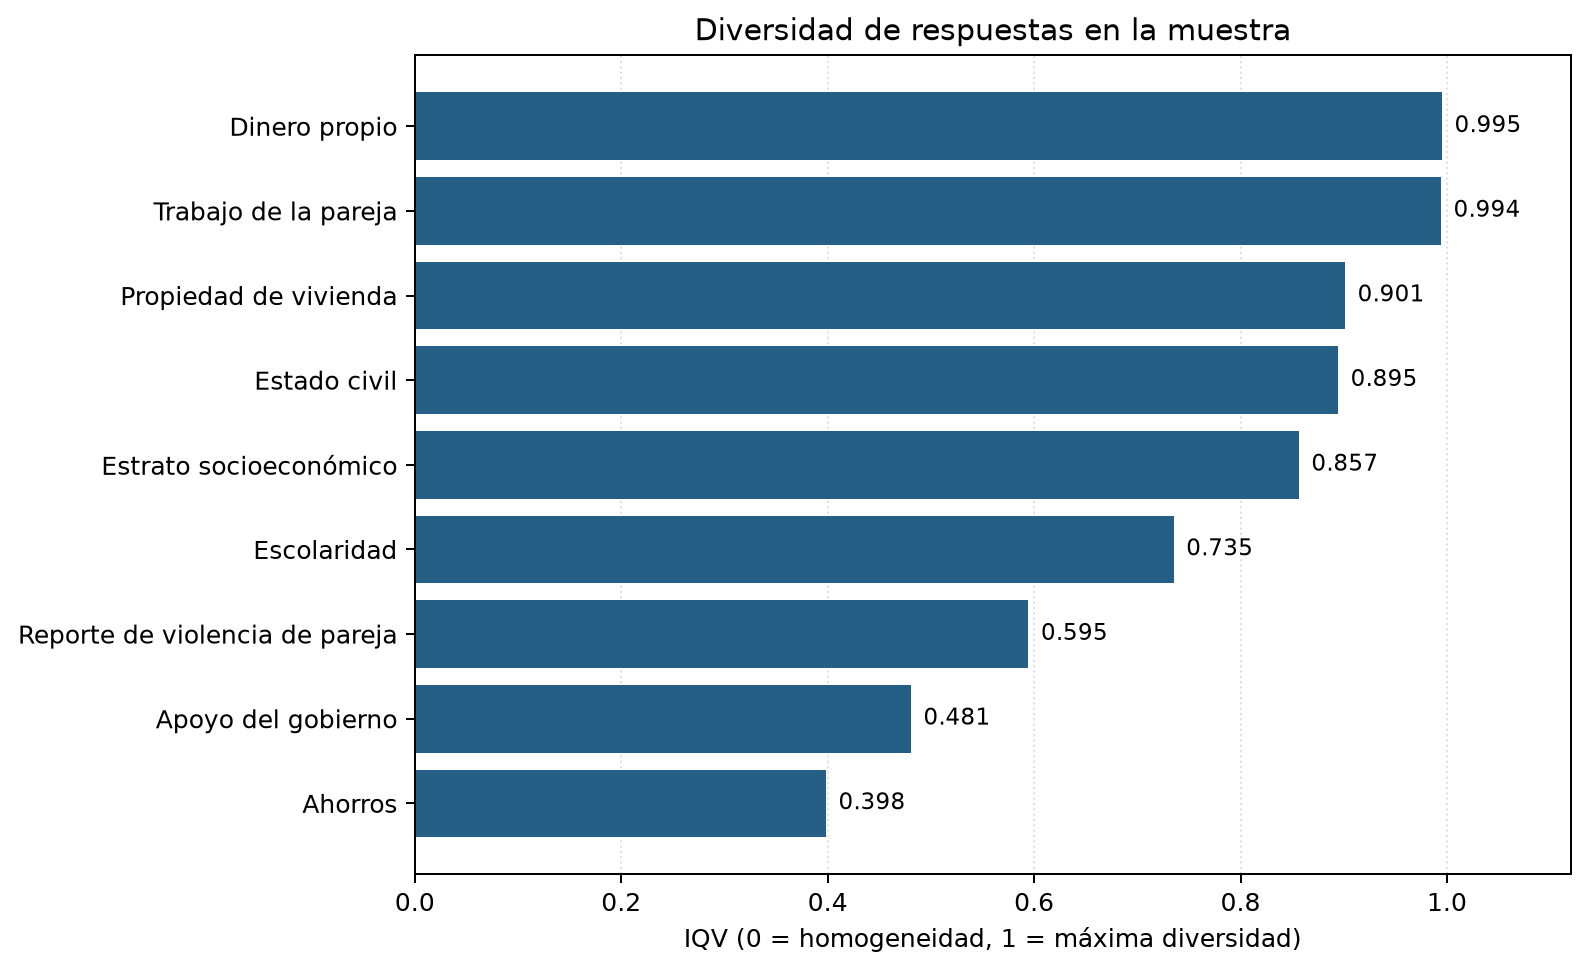

In [3]:
for nombre in ['07_barras_iqv.png']:
    display(Image(filename=RUTA_FIGURAS / nombre, width=850))

## Resultados por variable

- `dinero_propio_desc`: k=2, Gini-Simpson=0.4976, IQV=0.9952, Shannon=0.9965 bits.
- `pareja_trabaja_desc`: k=2, Gini-Simpson=0.4971, IQV=0.9943, Shannon=0.9959 bits.
- `propietaria_vivienda_desc`: k=2, Gini-Simpson=0.4507, IQV=0.9013, Shannon=0.9276 bits.
- `estado_civil_desc`: k=6, Gini-Simpson=0.7455, IQV=0.8945, Shannon=2.2176 bits.
- `estrato_socioeconomico`: k=4, Gini-Simpson=0.6424, IQV=0.8565, Shannon=1.7136 bits.
- `nivel_escolaridad`: k=6, Gini-Simpson=0.6127, IQV=0.7353, Shannon=1.8481 bits.
- `sufrio_violencia_pareja`: k=2, Gini-Simpson=0.2973, IQV=0.5945, Shannon=0.6836 bits.
- `apoyo_gobierno_desc`: k=2, Gini-Simpson=0.2403, IQV=0.4806, Shannon=0.5834 bits.
- `tiene_ahorros_desc`: k=2, Gini-Simpson=0.1992, IQV=0.3984, Shannon=0.5064 bits.

## Interpretación

Dinero propio y trabajo de la pareja tienen un IQV cercano a 1, así que sus respuestas están casi equilibradas. Ahorros tiene menor diversidad porque una respuesta aparece mucho más que la otra. La tabla de frecuencias permite ver cuál es.

El estado civil tiene bastante diversidad, aunque las seis categorías no tienen la misma frecuencia. En violencia de pareja predomina la respuesta de no haberla reportado. Esto describe la muestra, pero no alcanza para saber si existe subregistro.

In [4]:
for columna in ["tiene_ahorros_desc", "sufrio_violencia_pareja"]:
    display(df.group_by(columna).len().sort(columna))

tiene_ahorros_desc,len
str,u32
"""No""",93857
"""Sí""",11858


sufrio_violencia_pareja,len
u8,u32
0,86516
1,19199
